# Brain Tumor Detection using FasterRCNN-ResNet-50

## 1. Preparing Raw Dataset
- Many thanks to Ultralytics for providing the dataset used in this project.

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ultralytics/brain-tumor")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'brain-tumor' dataset.
Path to dataset files: /kaggle/input/brain-tumor


- Libraries

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
import pandas as pd
import yaml
import glob
import random
from PIL import Image
import torch
import torchvision
from torchvision.models.detection import FasterRCNN_ResNet50_FPN_Weights
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torch.utils.data import Dataset, DataLoader
from torch.utils.data import random_split
import torchvision.transforms as T
sns.set(style='darkgrid')

print(f"Using Torch version: {torch.__version__}")

Using Torch version: 2.9.0+cu126


In [3]:
yaml_path = os.path.join(path, "brain-tumor.yaml")
with open(yaml_path, "r") as f:
    bt_cfg = yaml.safe_load(f)

DATA_ROOT = os.path.join(path, "brain-tumor")

IM_TRAIN_DIR = os.path.join(DATA_ROOT, "train", "images")
LABEL_TRAIN_DIR = os.path.join(DATA_ROOT, "train", "labels")
IM_VAL_DIR = os.path.join(DATA_ROOT, "valid", "images")
LABEL_VAL_DIR = os.path.join(DATA_ROOT, "valid", "labels")

DATASET_CLASSES = [bt_cfg["names"][k] for k in sorted(bt_cfg["names"].keys())]
NUM_CLASSES = 1 + len(DATASET_CLASSES)  # + 1 for background
SEED = 42
CKPT_DIR = "/content/drive/MyDrive/fasterrcnncheckpoints"

## 2. Utils


In [4]:
def preprocess_image(image_path, labels_dir):
    im = Image.open(image_path).convert('RGB')
    w, h = im.size

    stem = os.path.splitext(os.path.basename(image_path))[0]
    label_path = os.path.join(labels_dir, stem + ".txt")

    boxes = []
    labels = []

    if os.path.exists(label_path):
        with open(label_path, "r") as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) != 5:
                    continue

                cls_id = int(parts[0])
                cx, cy, bw, bh = map(float, parts[1:])

                cx *= w
                cy *= h
                bw *= w
                bh *= h

                x1 = max(0, cx - bw / 2)
                y1 = max(0, cy - bh / 2)
                x2 = min(w, cx + bw / 2)
                y2 = min(h, cy + bh / 2)

                if x2 > x1 and y2 > y1:
                    boxes.append([x1, y1, x2, y2])
                    labels.append(cls_id + 1)
    if len(boxes) > 0:
        boxes = torch.tensor(boxes, dtype=torch.float32)
        labels = torch.tensor(labels, dtype=torch.int64)
    else:
        boxes = torch.zeros((0, 4), dtype=torch.float32)
        labels = torch.zeros((0,), dtype=torch.int64)

    image = torch.from_numpy(np.array(im)).permute(2, 0, 1).float() / 255.0

    return image, boxes, labels

def box_iou(boxes1, boxes2):
    area1 = (boxes1[:, 2] - boxes1[:, 0]) * (boxes1[:, 3] - boxes1[:, 1])
    area2 = (boxes2[:, 2] - boxes2[:, 0]) * (boxes2[:, 3] - boxes2[:, 1])

    lt = torch.max(boxes1[:, None, :2], boxes2[:, :2])
    rb = torch.min(boxes1[:, None, 2:], boxes2[:, 2:])

    wh = (rb - lt).clamp(min=0)
    inter = wh[:, :, 0] * wh[:, :, 1]

    union = area1[:, None] + area2 - inter
    return inter / union

def compute_metrics(results, class_id, iou_threshold=0.5):
    TP = 0
    FP = 0
    FN = 0

    for res in results:
        pred_boxes = res["boxes"][res["labels"] == class_id]
        gt_boxes = res["targets"]["boxes"][res["targets"]["labels"] == class_id]

        if len(pred_boxes) == 0 and len(gt_boxes) == 0:
            continue
        elif len(pred_boxes) == 0:
            FN += len(gt_boxes)
            continue
        elif len(gt_boxes) == 0:
            FP += len(pred_boxes)
            continue

        ious = box_iou(pred_boxes, gt_boxes)
        matched_gt = set()

        for i in range(ious.shape[0]):
            max_iou, idx = ious[i].max(0)
            idx = idx.item()
            if max_iou >= iou_threshold and idx not in matched_gt:
                TP += 1
                matched_gt.add(idx)
            else:
                FP += 1

        FN += len(gt_boxes) - len(matched_gt)

    return TP, FP, FN

def match_predictions(pred_boxes, pred_scores, gt_boxes, iou_threshold):
    if len(pred_boxes) == 0:
        return []

    if len(gt_boxes) == 0:
        return [(s.item(), False) for s in pred_scores]

    ious = box_iou(pred_boxes, gt_boxes)
    gt_used = torch.zeros(len(gt_boxes), dtype=torch.bool)

    matches = []

    for i in range(len(pred_boxes)):
        max_iou, gt_idx = ious[i].max(0)

        if max_iou >= iou_threshold and not gt_used[gt_idx]:
            matches.append((pred_scores[i].item(), True))
            gt_used[gt_idx] = True
        else:
            matches.append((pred_scores[i].item(), False))

    return matches

def precision_recall_curve(matches, num_gt):
    matches = sorted(matches, key=lambda x: x[0], reverse=True)

    tp = 0
    fp = 0

    precisions = []
    recalls = []

    for _, is_tp in matches:
        if is_tp:
            tp += 1
        else:
            fp += 1

        precision = tp / (tp + fp)
        recall = tp / num_gt if num_gt > 0 else 0

        precisions.append(precision)
        recalls.append(recall)

    return np.array(precisions), np.array(recalls)

def pr_curve(results, class_id, iou_threshold=0.5):
    matches = []
    total_gt = 0

    for res in results:
        preds = res
        gts = res["targets"]

        p_mask = preds["labels"] == class_id
        g_mask = gts["labels"] == class_id

        pred_boxes = preds["boxes"][p_mask]
        pred_scores = preds["scores"][p_mask]
        gt_boxes = gts["boxes"][g_mask]

        total_gt += len(gt_boxes)

        matches.extend(
            match_predictions(pred_boxes, pred_scores, gt_boxes, iou_threshold)
        )

    return precision_recall_curve(matches, total_gt)

def average_precision(precisions, recalls):
    recalls = np.concatenate(([0.0], recalls, [1.0]))
    precisions = np.concatenate(([0.0], precisions, [0.0]))

    for i in range(len(precisions) - 1, 0, -1):
        precisions[i - 1] = max(precisions[i - 1], precisions[i])

    idx = np.where(recalls[1:] != recalls[:-1])[0]
    ap = np.sum(
        (recalls[idx + 1] - recalls[idx]) * precisions[idx + 1]
    )
    return ap

def mean_ap(results, num_classes, iou_threshold):
    aps = []
    for class_id in range(1, num_classes + 1):
        p, r = pr_curve(results, class_id, iou_threshold)
        if len(p) == 0:
            aps.append(0.0)
        else:
            aps.append(average_precision(p, r))
    return sum(aps) / len(aps)

def map_50_90(results, num_classes):
    iou_thresholds = [0.5, 0.6, 0.7, 0.8, 0.9]
    map_per_iou = {}

    for t in iou_thresholds:
        map_per_iou[t] = mean_ap(results, num_classes, t)

    map5090 = sum(map_per_iou.values()) / len(map_per_iou)
    return map5090, map_per_iou

def plot_pr_curve(results, num_classes, iou_threshold=0.5):
    plt.figure(figsize=(6, 4))

    for class_id in range(1, num_classes + 1):
        precisions, recalls = pr_curve(results, class_id, iou_threshold)

        if len(precisions) == 0:
            continue

        plt.plot(
            recalls,
            precisions,
            label="Class=" + ("Positive" if class_id == 2 else "Negative")
        )

    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"PR Curve (IoU={iou_threshold})")
    plt.legend()
    plt.grid()
    plt.show()

def plot_map_50_90(map_per_iou):
    ious = sorted(map_per_iou.keys())
    maps = [map_per_iou[iou] for iou in ious]

    plt.figure(figsize=(6, 4))
    plt.plot(
        ious,
        maps,
        marker="o",
        linewidth=2
    )

    plt.xlabel("IoU Threshold")
    plt.ylabel("mAP")
    plt.title("mAP@0.5–0.9")
    plt.xticks(ious)
    plt.grid()
    plt.show()

## 3. Setup Datasets and DataLoaders

In [5]:
class BrainTumorYoloDataset(Dataset):
    def __init__(self, images_dir, labels_dir):
        self.images_dir = images_dir
        self.labels_dir = labels_dir
        self.image_paths = sorted(glob.glob(os.path.join(images_dir, "*.jpg")))

        print(f"Found {len(self.image_paths)} images in {images_dir}")

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image, boxes, labels = preprocess_image(img_path, self.labels_dir)

        target = {
            "boxes": boxes,    # [N,4]
            "labels": labels,  # [N]
        }

        return image, target, img_path

In [6]:
def collate_fn(batch):
    images, targets, fnames = zip(*batch)
    return list(images), list(targets), fnames

In [7]:
# Datasets
full_train_dataset = BrainTumorYoloDataset(IM_TRAIN_DIR, LABEL_TRAIN_DIR)
test_dataset = BrainTumorYoloDataset(IM_VAL_DIR, LABEL_VAL_DIR)

# Split train / val
train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size
train_dataset, val_dataset = random_split(
    full_train_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED)
)

# Dataloaders
train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True,
    num_workers=2,
    collate_fn=collate_fn
)

val_loader = DataLoader(
    val_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=2,
    collate_fn=collate_fn
)

test_loader = DataLoader(
    test_dataset,
    batch_size=1,
    shuffle=False,
    num_workers=2,
    collate_fn=collate_fn
)

Found 893 images in /kaggle/input/brain-tumor/brain-tumor/train/images
Found 223 images in /kaggle/input/brain-tumor/brain-tumor/valid/images


## 4. Setup Model

In [8]:
history = {
    "epoch": [],
    "train_box_loss": [],
    "train_cls_loss": [],
    "train_obj_loss": [],
    "train_rpn_box_loss" : [],
    "precision": [],
    "recall": [],
    "map50": [],
    "map5095": [],
}

In [9]:
def get_model(num_classes):
    # Load a pre-trained weights
    model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT)

    # num_classes includes background
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

    return model

## 5. Setup Training and Evaluation Loops

In [10]:
def train_one_epoch(model, optimizer, data_loader, device):
    model.train()

    loss_box = 0
    loss_cls = 0
    loss_rpn = 0
    loss_obj = 0

    total_loss = 0.0

    for images, targets, _ in data_loader:
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)

        losses = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

        loss_box += loss_dict["loss_box_reg"].item()
        loss_cls += loss_dict["loss_classifier"].item()
        loss_rpn += loss_dict["loss_rpn_box_reg"].item()
        loss_obj += loss_dict["loss_objectness"].item()

        total_loss += losses.item()

        n = len(data_loader)

    return total_loss / n, {"box": loss_box / n, "cls": loss_cls / n, "rpn": loss_rpn / n, "obj": loss_obj / n}


In [11]:
def evaluate(model, val_loader, device):
    model.eval()
    results = []

    with torch.no_grad():
        for images, targets, _ in val_loader:
            images = [img.to(device) for img in images]
            outputs = model(images)

            for i, out in enumerate(outputs):
                results.append({
                    "boxes": out["boxes"].cpu(),
                    "scores": out["scores"].cpu(),
                    "labels": out["labels"].cpu(),
                    "targets": {k: v.cpu() for k, v in targets[i].items()}
                })

    return results

## 6. Execution

In [12]:
from google.colab import drive
drive.mount('/content/drive')
os.makedirs(CKPT_DIR, exist_ok=True)

Mounted at /content/drive


In [13]:
def main():
    device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

    model = get_model(NUM_CLASSES)
    model.to(device)

    optimizer = torch.optim.SGD(
        model.parameters(),
        lr=0.005,
        momentum=0.9,
        weight_decay=0.0005
    )

    num_epochs = 10

    for epoch in range(num_epochs):
        total_loss, loss_dict = train_one_epoch(model, optimizer, train_loader, device)
        print(f"Epoch: {epoch+1}/{num_epochs} - Loss: {total_loss:.4f}")

        results = evaluate(model, val_loader, device)

        map50 = mean_ap(results, num_classes=2, iou_threshold=0.5)
        map5090, _ = map_50_90(results, num_classes=2)

        history["epoch"].append(epoch + 1)
        history["train_box_loss"].append(loss_dict["box"])
        history["train_cls_loss"].append(loss_dict["cls"])
        history["train_obj_loss"].append(loss_dict["obj"])
        history["train_rpn_box_loss"].append(loss_dict["rpn"])

        total_TP = 0
        total_FP = 0
        total_FN = 0

        for cls in range(1, NUM_CLASSES):
            TP, FP, FN = compute_metrics(results, class_id=cls, iou_threshold=0.5)
            total_TP += TP
            total_FP += FP
            total_FN += FN

        p = total_TP / (total_TP + total_FP) if (total_TP + total_FP) > 0 else 0
        r = total_TP / (total_TP + total_FN) if (total_TP + total_FN) > 0 else 0

        history["precision"].append(p)
        history["recall"].append(r)

        history["map50"].append(map50)
        history["map5095"].append(map5090)

        ckpt_path = f"{CKPT_DIR}/model_epoch_{epoch+1}.pth"
        torch.save(model.state_dict(), ckpt_path)


    torch.save(model.state_dict(), f"{CKPT_DIR}/model.pth")
    print("Training finished!")

if __name__ == "__main__":
    main()


Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:00<00:00, 214MB/s]


Epoch: 1/10 - Loss: 0.2511
Epoch: 2/10 - Loss: 0.1400
Epoch: 3/10 - Loss: 0.1126
Epoch: 4/10 - Loss: 0.0963
Epoch: 5/10 - Loss: 0.0869
Epoch: 6/10 - Loss: 0.0798
Epoch: 7/10 - Loss: 0.0708
Epoch: 8/10 - Loss: 0.0637
Epoch: 9/10 - Loss: 0.0583
Epoch: 10/10 - Loss: 0.0511
Training finished!


## 7. Metrics Visualization

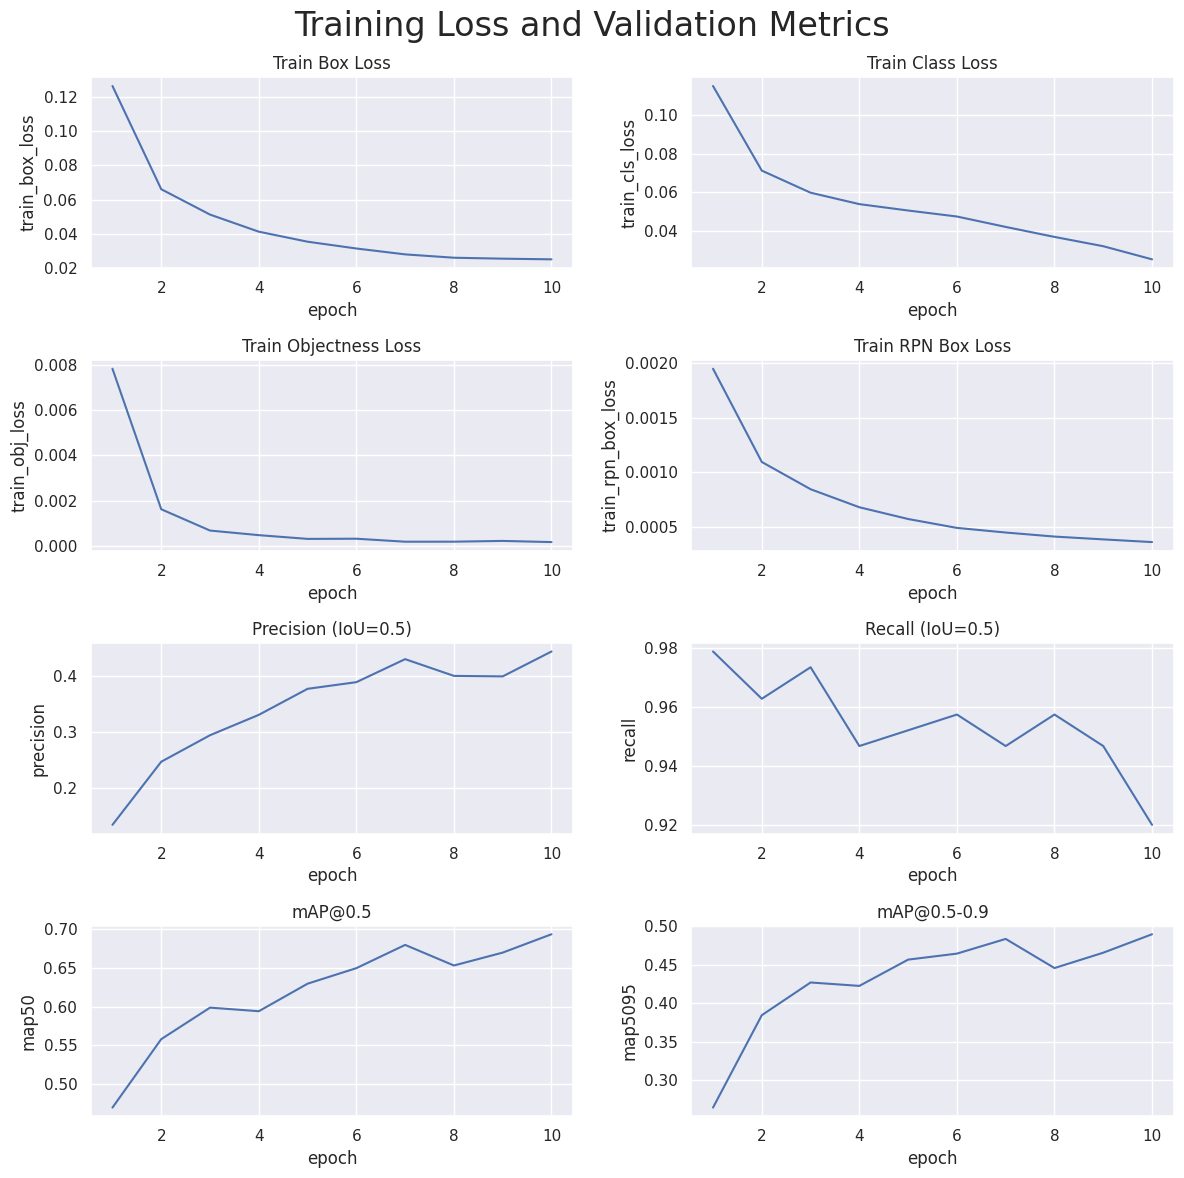

In [14]:
df_metrics = pd.DataFrame(history)
fig, axs = plt.subplots(nrows=4, ncols=2, figsize=(12, 12))

sns.lineplot(x='epoch', y='train_box_loss', data=df_metrics, ax=axs[0,0])
sns.lineplot(x='epoch', y='train_cls_loss', data=df_metrics, ax=axs[0,1])
sns.lineplot(x='epoch', y='train_obj_loss', data=df_metrics, ax=axs[1,0])
sns.lineplot(x='epoch', y='train_rpn_box_loss', data=df_metrics, ax=axs[1,1])
sns.lineplot(x='epoch', y='precision', data=df_metrics, ax=axs[2,0])
sns.lineplot(x='epoch', y='recall', data=df_metrics, ax=axs[2,1])
sns.lineplot(x='epoch', y='map50', data=df_metrics, ax=axs[3,0])
sns.lineplot(x='epoch', y='map5095', data=df_metrics, ax=axs[3,1])

axs[0,0].set(title='Train Box Loss')
axs[0,1].set(title='Train Class Loss')
axs[1,0].set(title='Train Objectness Loss')
axs[1,1].set(title='Train RPN Box Loss')
axs[2,0].set(title='Precision (IoU=0.5)')
axs[2,1].set(title='Recall (IoU=0.5)')
axs[3,0].set(title='mAP@0.5')
axs[3,1].set(title='mAP@0.5-0.9')

plt.suptitle('Training Loss and Validation Metrics', fontsize=24)
plt.subplots_adjust(top=1)
plt.tight_layout()
plt.show()

## 8. Testing

In [15]:
def test(model, test_loader, device, score_thresh=0.5):
    model.eval()
    all_results = []

    with torch.no_grad():
        for images, targets, img_paths in test_loader:
            images = [img.to(device) for img in images]

            outputs = model(images)

            for i, output in enumerate(outputs):
                boxes = output["boxes"].cpu()
                labels = output["labels"].cpu()
                scores = output["scores"].cpu()

                keep = scores >= score_thresh

                all_results.append({
                    "image": img_paths[i],
                    "boxes": boxes[keep],
                    "labels": labels[keep],
                    "scores": scores[keep],
                    "targets": targets[i]
                })

            del outputs, images
            torch.cuda.empty_cache()

    return all_results

- Load the checkpoints back

In [16]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = get_model(NUM_CLASSES)
model.load_state_dict(torch.load(f"{CKPT_DIR}/model.pth", map_location=device))
model.to(device)

results = test(model, test_loader, device)

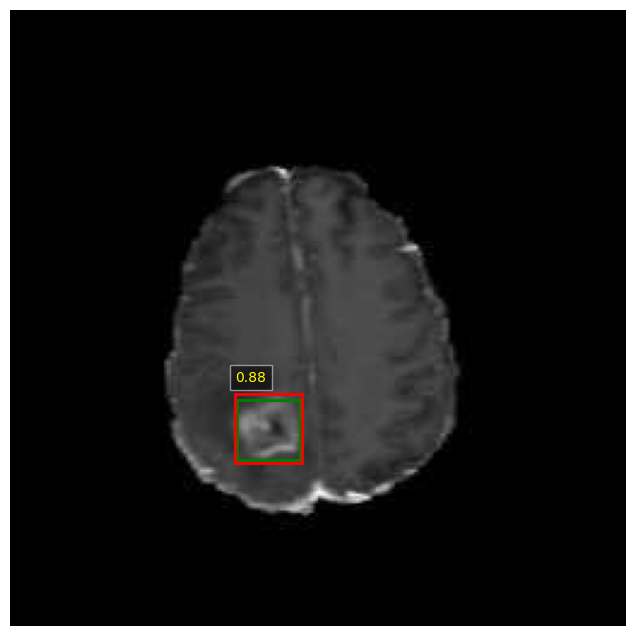

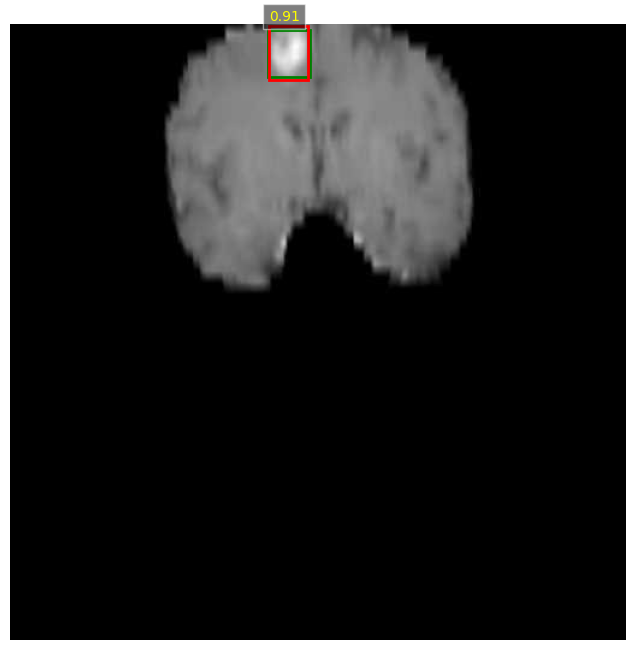

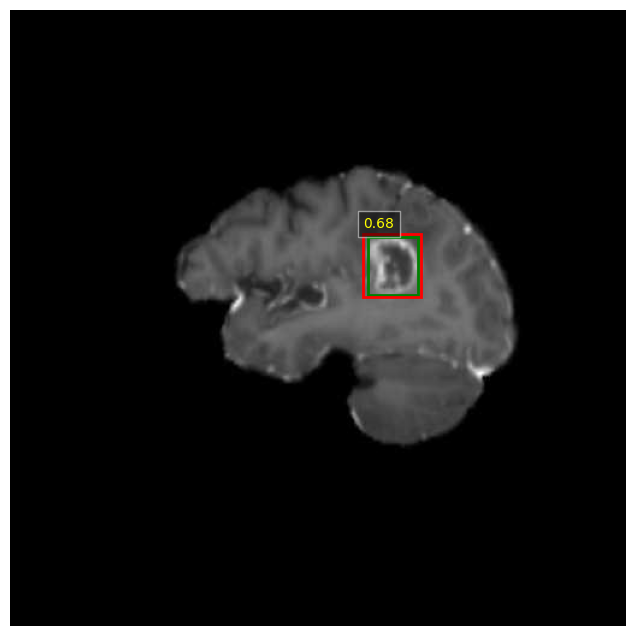

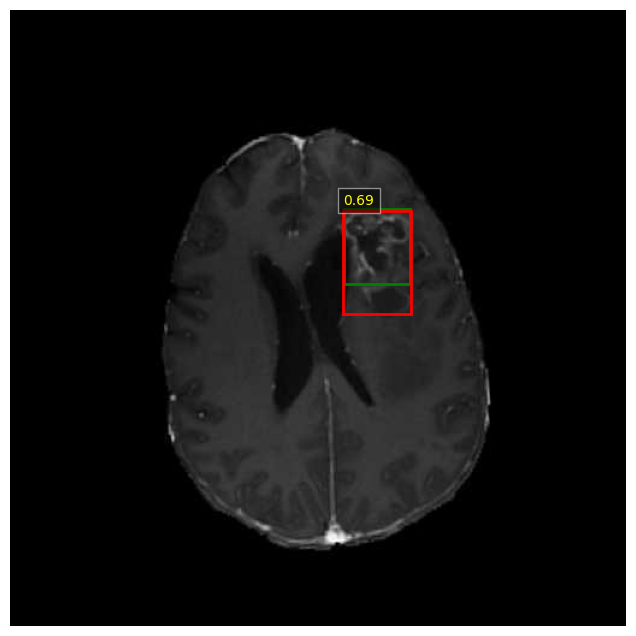

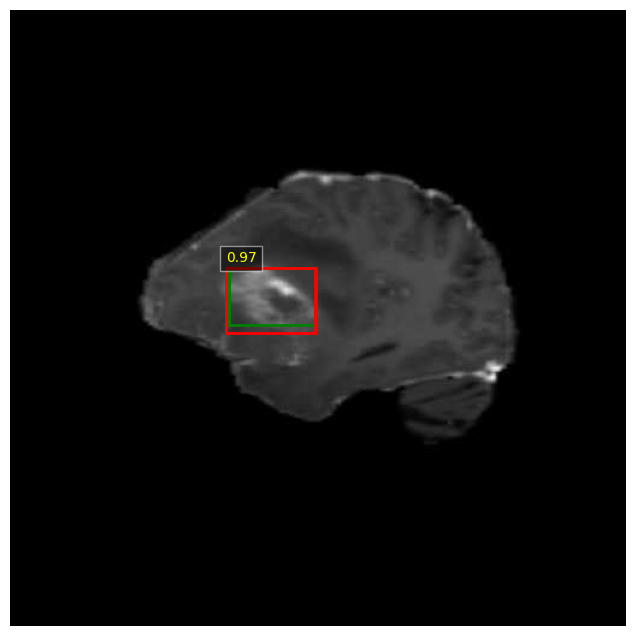

In [19]:
def show_predictions(results, num_images=5):

    samples = random.sample(results, min(num_images, len(results)))

    for res in samples:
        img = Image.open(res["image"]).convert("RGB")
        boxes = res["boxes"]
        scores = res["scores"]
        gt_boxes = res["targets"]["boxes"]
        fig, ax = plt.subplots(1, figsize=(8, 8))
        ax.imshow(img)
        ax.axis("off")

        for gt_box in gt_boxes:
            x1, y1, x2, y2 = gt_box.tolist()
            rect = patches.Rectangle(
                (x1, y1),
                x2 - x1,
                y2 - y1,
                linewidth=2,
                edgecolor="green",
                facecolor="none"
            )
            ax.add_patch(rect)

        for box, score in zip(boxes, scores):
            x1, y1, x2, y2 = box.tolist()
            rect = patches.Rectangle(
                (x1, y1),
                x2 - x1,
                y2 - y1,
                linewidth=2,
                edgecolor="red",
                facecolor="none"
            )
            ax.add_patch(rect)

            ax.text(
                x1,
                y1 - 5,
                f"{score:.2f}",
                color="yellow",
                fontsize=10,
                bbox=dict(facecolor="black", alpha=0.5)
            )

        plt.show()

show_predictions(results, num_images=5)